In [6]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from tvm.auto_scheduler import RecordReader

GROUND_TRUTH_PATH = '/root/work/tvm-ansor/gallery/constrained_gen/data/to_measure_ansor/1490_ansor_([3eda1939e30b947e921f5e1814346365,[1,56,56,128],[6,6,32,128],[1,56,56,32]],cuda).json'
GENERATED_PATH = '/root/work/tvm-ansor/gallery/dataset/to_measure_gen_programs/([3eda1939e30b947e921f5e1814346365,[1,56,56,128],[6,6,32,128],[1,56,56,32]],cuda).json'

print(GROUND_TRUTH_PATH)
print(GENERATED_PATH)

/root/work/tvm-ansor/gallery/constrained_gen/data/to_measure_ansor/1490_ansor_([3eda1939e30b947e921f5e1814346365,[1,56,56,128],[6,6,32,128],[1,56,56,32]],cuda).json
/root/work/tvm-ansor/gallery/dataset/to_measure_gen_programs/([3eda1939e30b947e921f5e1814346365,[1,56,56,128],[6,6,32,128],[1,56,56,32]],cuda).json


In [7]:
def load_split_step_counters(path):
    inputs, results = RecordReader(str(path)).read_lines()
    counters = {}
    step_meta = {}
    for inp in inputs:
        for step_idx, step in enumerate(inp.state.transform_steps):
            if step.type_key.split('.')[-1] != 'SplitStep':
                continue
            lengths = tuple(int(x) if x is not None else None for x in step.lengths)
            counters.setdefault(step_idx, Counter())[lengths] += 1
            step_meta[step_idx] = {
                'stage_id': int(step.stage_id),
                'iter_id': int(step.iter_id),
                'extent': int(step.extent) if step.extent is not None else None,
            }
    return inputs, results, counters, step_meta


def merge_step_meta(gt_step_meta, gen_step_meta):
    merged = {}
    for step_idx in sorted(set(gt_step_meta) | set(gen_step_meta)):
        gt_meta = gt_step_meta.get(step_idx)
        gen_meta = gen_step_meta.get(step_idx)
        base_meta = dict(gt_meta or gen_meta)
        base_meta['gen_extent'] = (gen_meta or base_meta)['extent']
        base_meta['meta_mismatch'] = bool(gt_meta and gen_meta and gt_meta != gen_meta)
        merged[step_idx] = base_meta
    return merged


gt_inputs, gt_results, gt_counters, gt_step_meta = load_split_step_counters(GROUND_TRUTH_PATH)
gen_inputs, gen_results, gen_counters, gen_step_meta = load_split_step_counters(GENERATED_PATH)
step_meta = merge_step_meta(gt_step_meta, gen_step_meta)
split_steps = sorted(step_meta)

print('ground truth records:', len(gt_inputs))
print('generated records:', len(gen_inputs))
print('split steps:', split_steps)
print('metadata mismatches:', [idx for idx, meta in step_meta.items() if meta['meta_mismatch']])

ground truth records: 4000
generated records: 4000
split steps: [2, 3, 9, 10, 11, 12, 13, 27, 28, 36, 40, 50, 55, 60]
metadata mismatches: [50, 55]


In [8]:
def distribution(counter):
    total = sum(counter.values())
    if total == 0:
        return {}
    return {k: v / total for k, v in counter.items()}


def total_variation_distance(counter_a, counter_b):
    dist_a = distribution(counter_a)
    dist_b = distribution(counter_b)
    support = set(dist_a) | set(dist_b)
    return 0.5 * sum(abs(dist_a.get(k, 0.0) - dist_b.get(k, 0.0)) for k in support)


def overlap_mass(counter_a, counter_b):
    dist_a = distribution(counter_a)
    dist_b = distribution(counter_b)
    support = set(dist_a) | set(dist_b)
    return sum(min(dist_a.get(k, 0.0), dist_b.get(k, 0.0)) for k in support)


summary_rows = []
for step_idx in split_steps:
    gt_counter = gt_counters.get(step_idx, Counter())
    gen_counter = gen_counters.get(step_idx, Counter())
    meta = step_meta[step_idx]
    summary_rows.append({
        'step_idx': step_idx,
        'stage_id': meta['stage_id'],
        'iter_id': meta['iter_id'],
        'extent': meta['extent'],
        'gen_extent': meta['gen_extent'],
        'meta_mismatch': meta['meta_mismatch'],
        'gt_records': sum(gt_counter.values()),
        'gen_records': sum(gen_counter.values()),
        'gt_support': len(gt_counter),
        'gen_support': len(gen_counter),
        'tv_distance': total_variation_distance(gt_counter, gen_counter),
        'overlap_mass': overlap_mass(gt_counter, gen_counter),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('step_idx').reset_index(drop=True)
summary_df

,step_idx,stage_id,iter_id,extent,gen_extent,meta_mismatch,gt_records,gen_records,gt_support,gen_support,tv_distance,overlap_mass
0,2,8,2,196,196,False,4000,4000,7,7,0.19225,0.80775
1,3,8,4,32,32,False,4000,4000,6,6,0.17025,0.82975
2,9,6,0,6,6,False,4000,4000,25,6,0.52325,0.47675
3,10,6,5,6,6,False,4000,4000,25,9,0.71075,0.28925
4,11,6,10,196,196,False,4000,4000,107,12,0.90750,0.09250
5,12,6,15,32,32,False,4000,4000,93,3,0.96925,0.03075
6,13,6,20,128,128,False,4000,4000,28,26,0.47025,0.52975
7,27,4,2,196,196,False,4000,4000,7,7,0.21600,0.78400
8,28,4,4,128,128,False,4000,4000,7,7,0.21450,0.78550
9,36,12,0,100352,100352,False,4000,4000,12,12,0.42275,0.57725


In [9]:
TOP_TABLE_COLUMNS = ['family', 'gt_count', 'gt_prob', 'gen_count', 'gen_prob', 'abs_diff']


def top_table(step_idx, top_k=15):
    gt_counter = gt_counters.get(step_idx, Counter())
    gen_counter = gen_counters.get(step_idx, Counter())
    gt_total = sum(gt_counter.values())
    gen_total = sum(gen_counter.values())
    support = set(gt_counter) | set(gen_counter)
    if not support:
        return pd.DataFrame(columns=TOP_TABLE_COLUMNS)

    rows = []
    for family in support:
        rows.append({
            'family': str(family),
            'gt_count': gt_counter.get(family, 0),
            'gt_prob': gt_counter.get(family, 0) / gt_total if gt_total else 0.0,
            'gen_count': gen_counter.get(family, 0),
            'gen_prob': gen_counter.get(family, 0) / gen_total if gen_total else 0.0,
            'abs_diff': abs(
                (gt_counter.get(family, 0) / gt_total if gt_total else 0.0)
                - (gen_counter.get(family, 0) / gen_total if gen_total else 0.0)
            ),
        })
    return pd.DataFrame(rows, columns=TOP_TABLE_COLUMNS).sort_values(
        ['abs_diff', 'gt_prob', 'gen_prob'], ascending=False
    ).head(top_k)


example_step_idx = int(summary_df.iloc[0]['step_idx']) if not summary_df.empty else None
if example_step_idx is not None:
    top_table(example_step_idx, top_k=20)

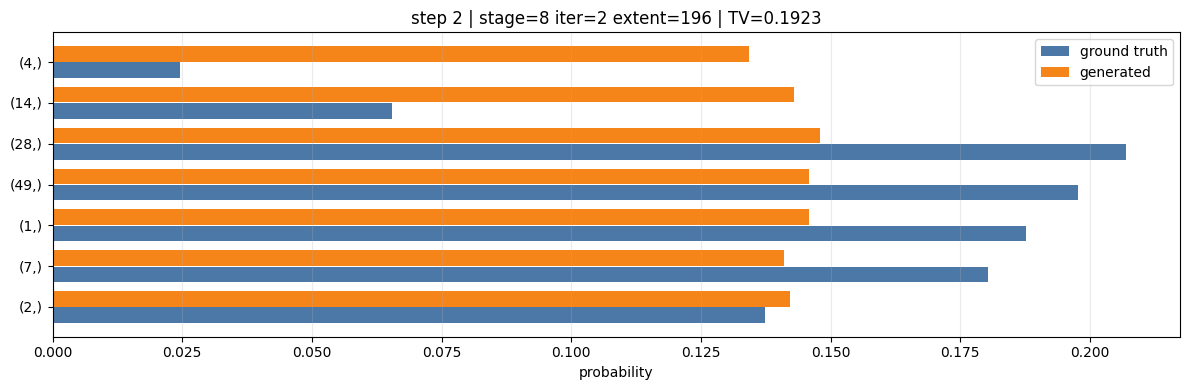

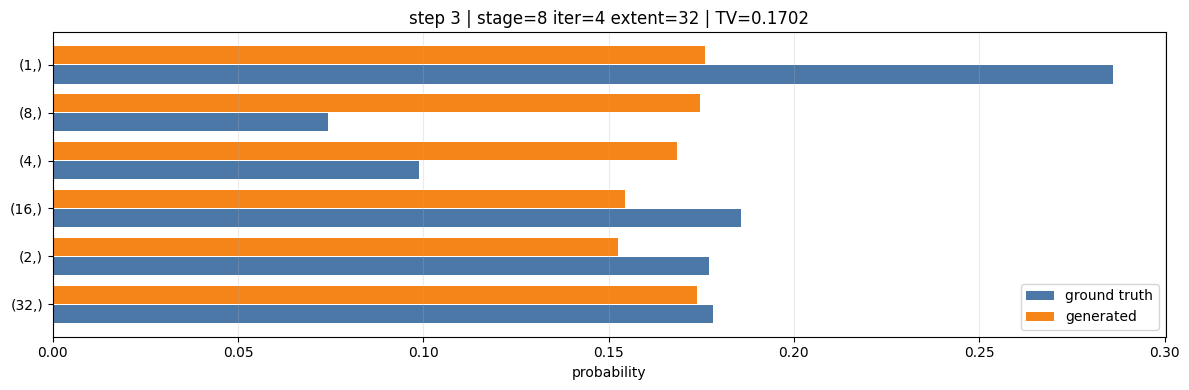

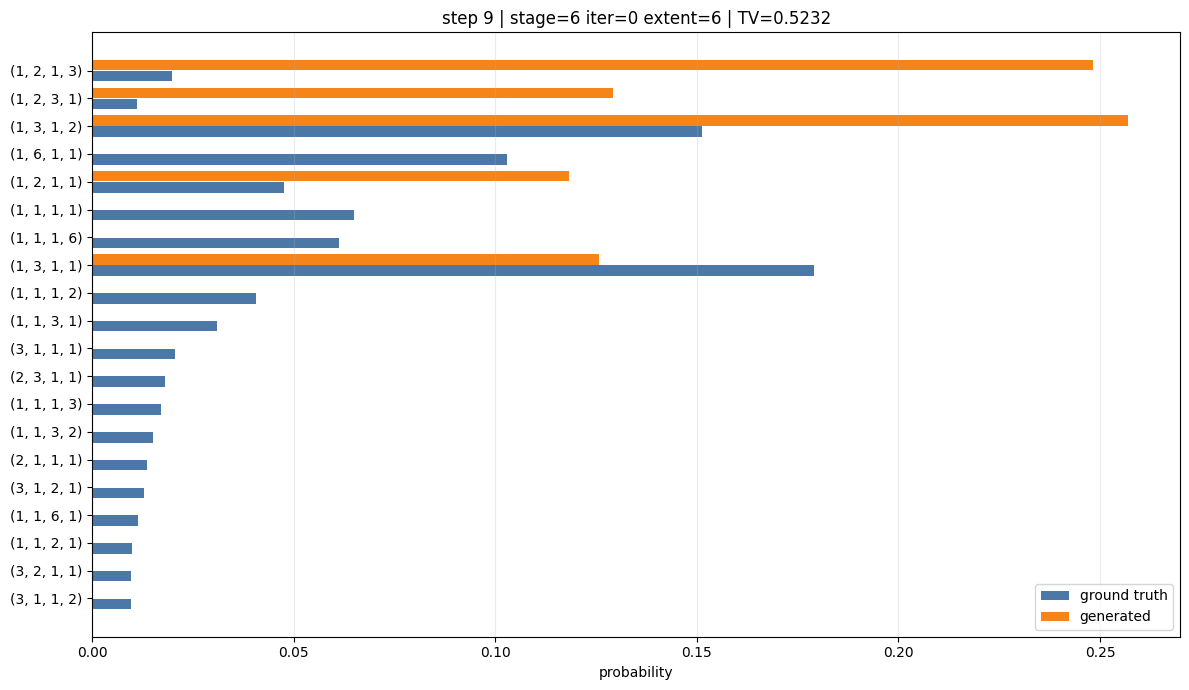

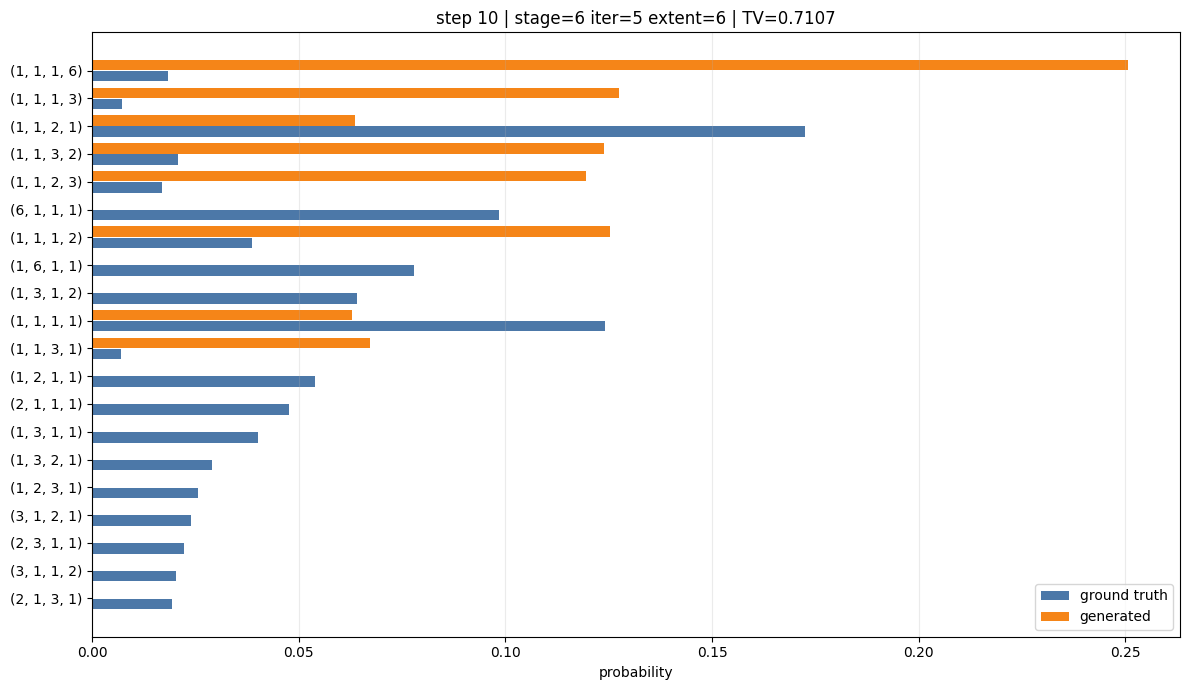

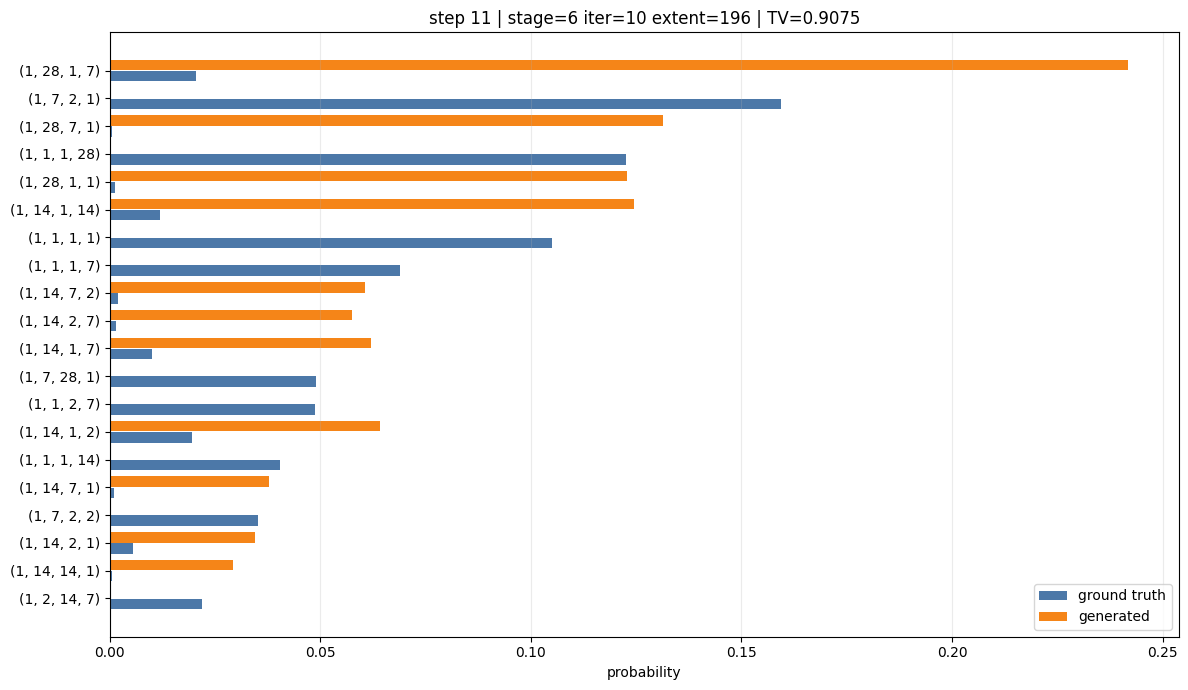

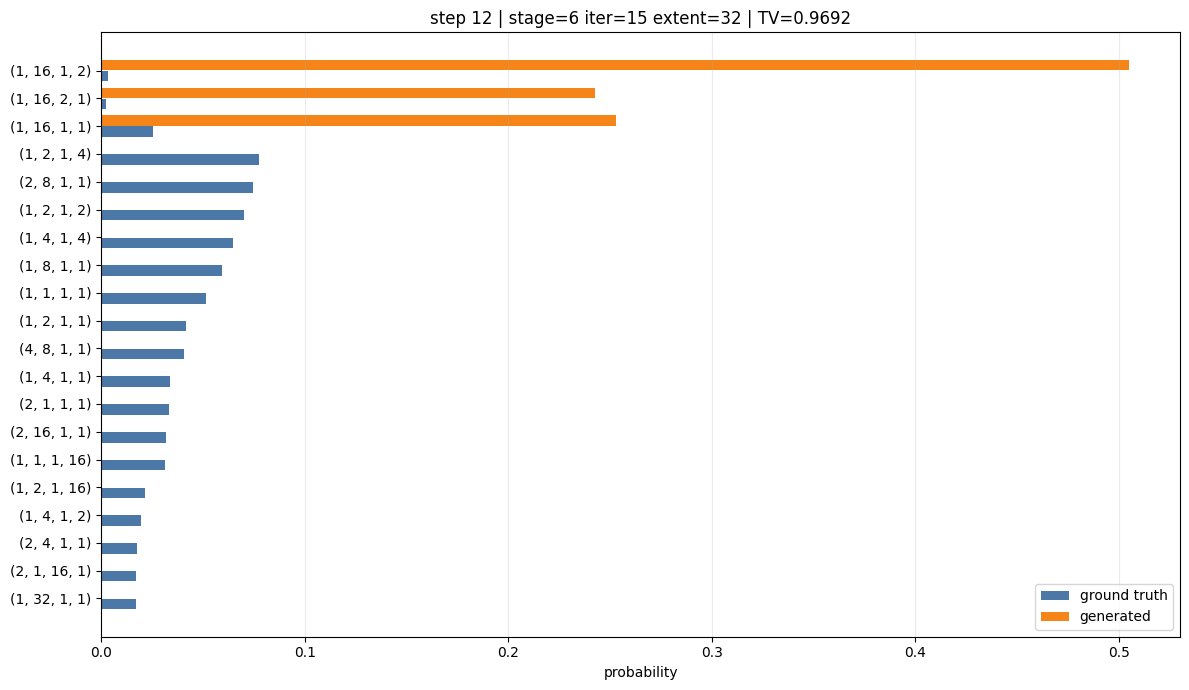

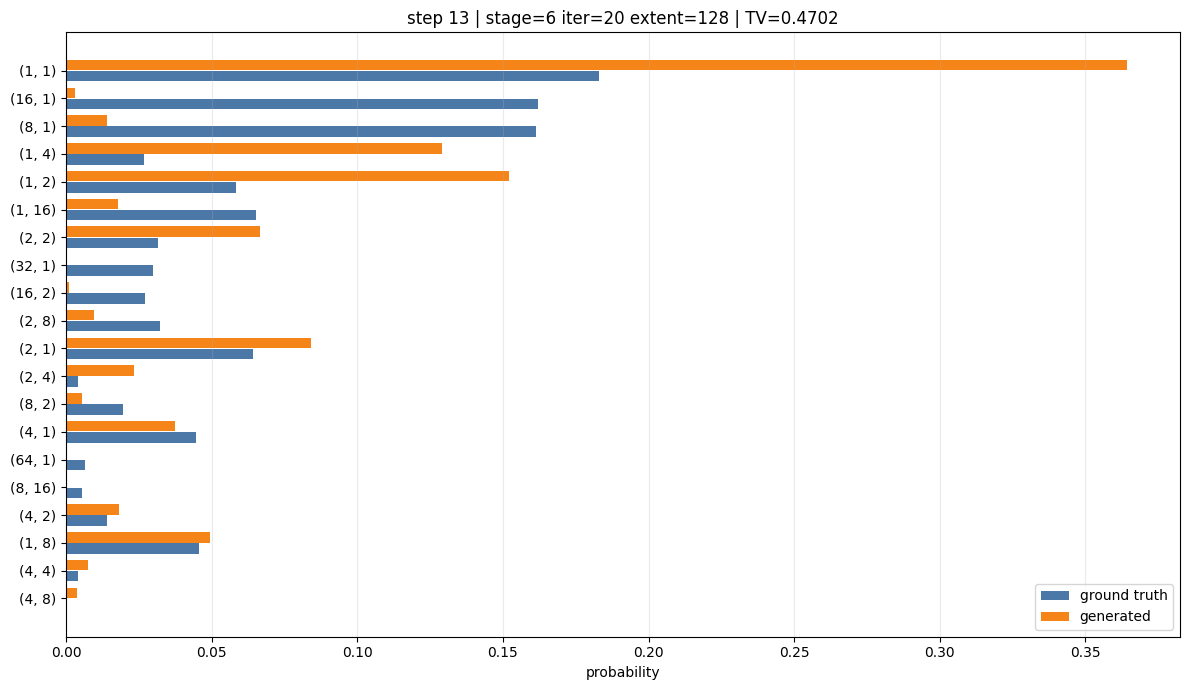

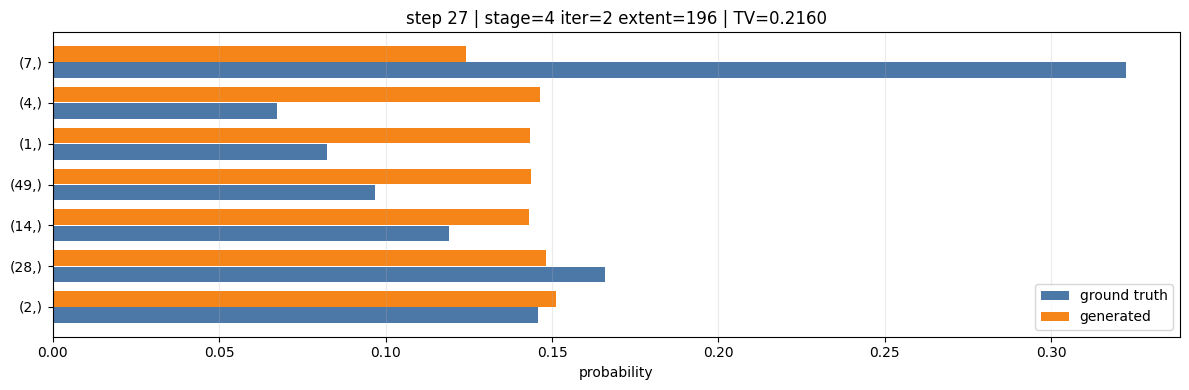

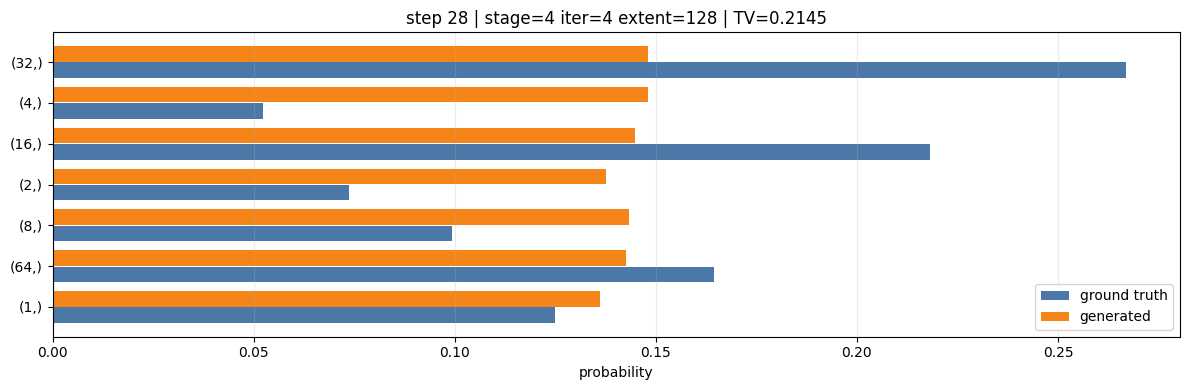

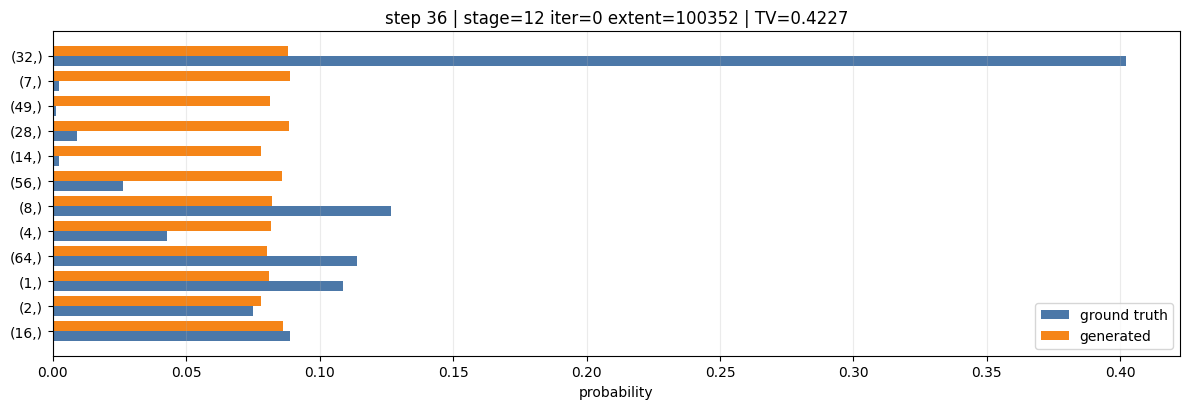

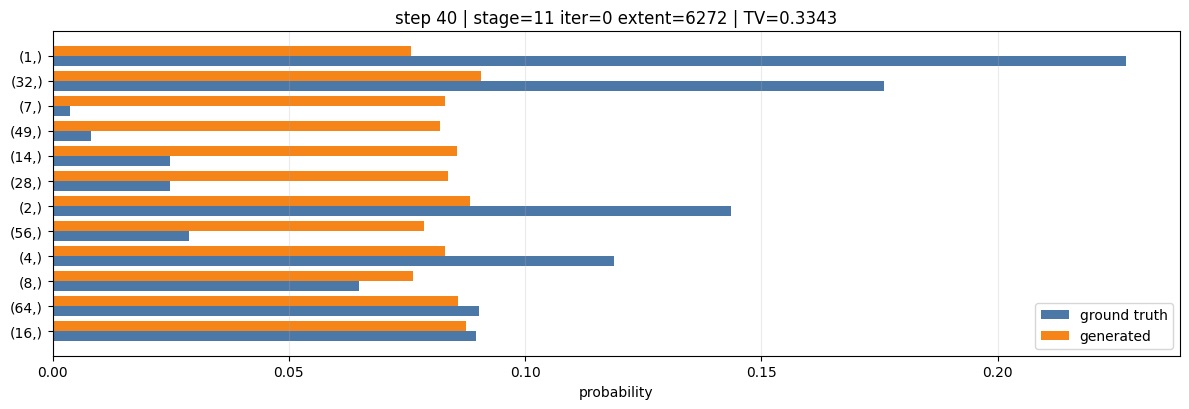

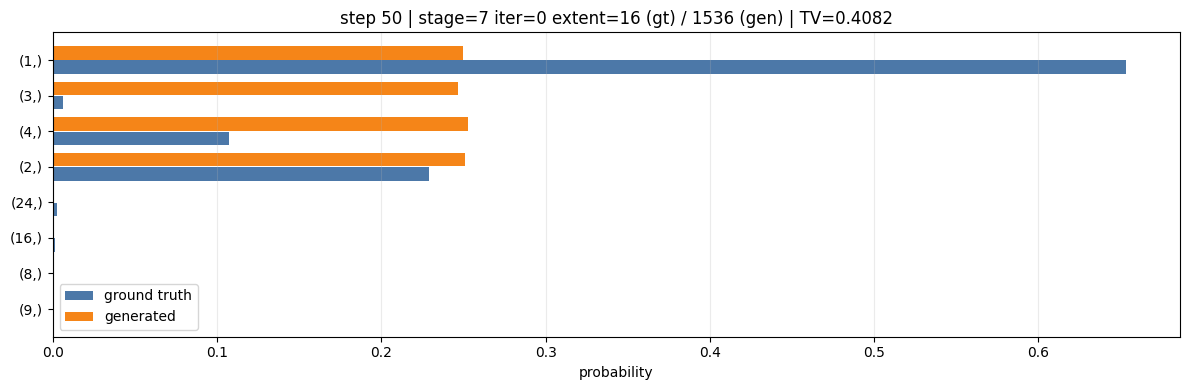

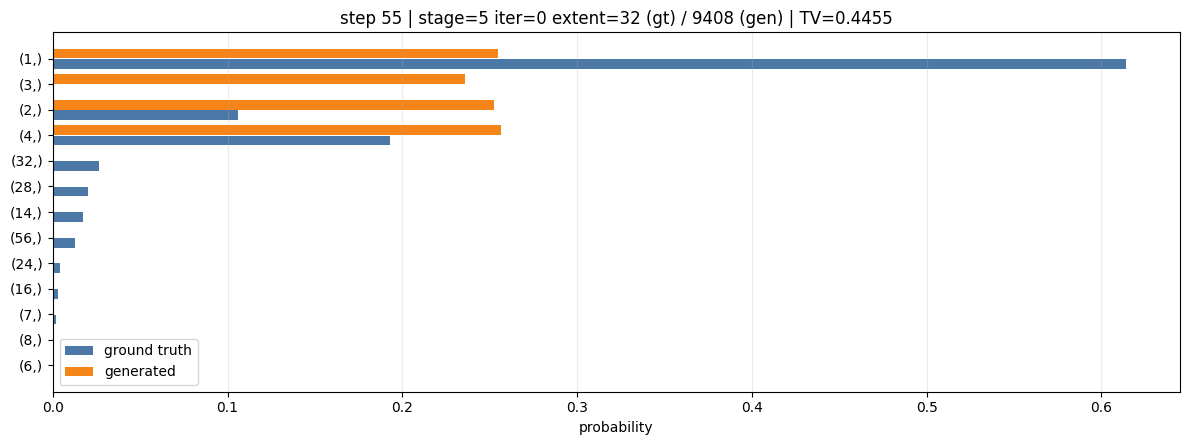

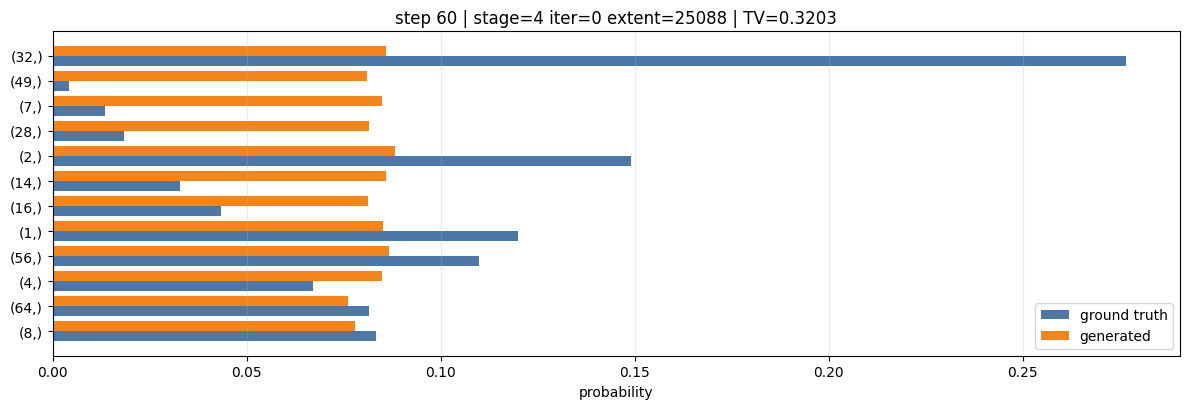

In [10]:
def plot_step_distribution(step_idx, top_k=20):
    df = top_table(step_idx, top_k=top_k).iloc[::-1]
    if df.empty:
        print(f'No split data for step {step_idx}')
        return

    meta = step_meta[step_idx]
    extent_text = meta['extent']
    if meta.get('meta_mismatch'):
        extent_text = f"{meta['extent']} (gt) / {meta['gen_extent']} (gen)"
    fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * len(df))))
    y = range(len(df))
    ax.barh([i - 0.2 for i in y], df['gt_prob'], height=0.38, label='ground truth', color='#4c78a8')
    ax.barh([i + 0.2 for i in y], df['gen_prob'], height=0.38, label='generated', color='#f58518')
    ax.set_yticks(list(y))
    ax.set_yticklabels(df['family'])
    ax.set_xlabel('probability')
    ax.set_title(
        f'step {step_idx} | stage={meta["stage_id"]} iter={meta["iter_id"]} extent={extent_text} '
        f'| TV={total_variation_distance(gt_counters.get(step_idx, Counter()), gen_counters.get(step_idx, Counter())):.4f}'
    )
    ax.legend()
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()


for step_idx in summary_df.loc[summary_df['gt_support'] > 1, 'step_idx']:
    plot_step_distribution(int(step_idx), top_k=20)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_df = summary_df.copy()
plot_df['label'] = plot_df.apply(lambda row: f"{int(row['step_idx'])}\n(s{int(row['stage_id'])},i{int(row['iter_id'])})", axis=1)
ax.bar(plot_df['label'], plot_df['tv_distance'], color='#e45756')
ax.set_ylabel('total variation distance')
ax.set_title('Per-step distribution gap')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()